In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (confusion_matrix, classification_report, 
                             roc_curve, roc_auc_score, silhouette_score)
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure visualization
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [4]:
mental_cluster_dataset = pd.read_csv('mental_health_clusters.csv')

In [5]:
print(mental_cluster_dataset)

      Depression   Anxiety  Schizophrenia   Bipolar  Cluster
0       7.496714  1.324822       1.136506 -0.114081        2
1       6.861736  1.855481       1.968797  0.369069        2
2       7.647689  1.207580       2.018017  0.057940        2
3       8.523030  1.692038       2.472630  0.452004        2
4       6.765847  0.106385       0.633142  0.785850        2
...          ...       ...            ...       ...      ...
7995    5.754598  4.118546       5.422712  4.697966        1
7996    6.548978  2.819565       7.444604  2.155241        1
7997    6.956417  4.642550       5.498633  3.790033        1
7998    4.397076  2.299935       4.107643  3.465433        1
7999    5.696799  4.184238       5.771116  3.665419        1

[8000 rows x 5 columns]


In [15]:
print(mental_cluster_dataset['Cluster'].value_counts())

Cluster
1    2014
0    2002
3    2000
2    1984
Name: count, dtype: int64


# First Attempt at  pre-processed visualization 

Because the data is somewhat categorical when bunched together, I tried to consider an additional numerical value I could use to compare an already clusered dataset at once, and I thought I would use the index as the x value and the Cluster column as the Y value.

I thought this would be a way to discretely look at the amounts per cluster, though I likely could've also tried using the .value_counts() function.

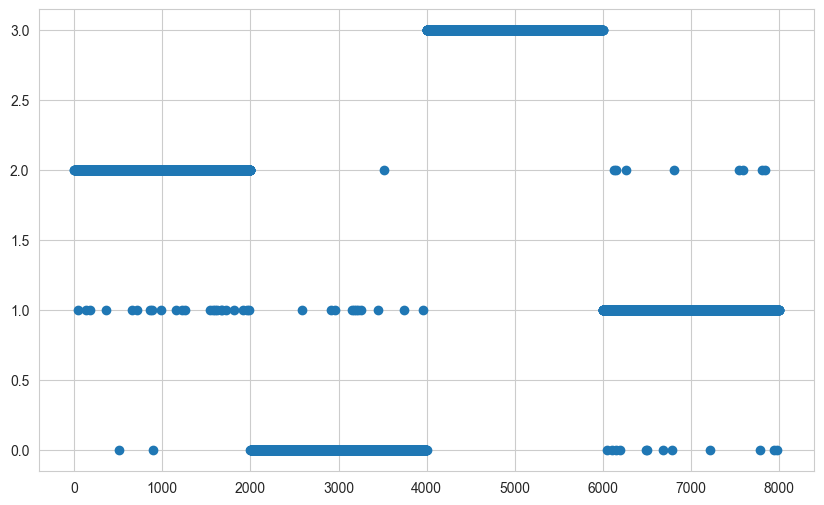

In [ ]:
fig, ax = plt.subplots()
ax.scatter(mental_cluster_dataset.index, mental_cluster_dataset['Cluster'] )
ax[0, 0].set_xlabel('Count of items in dataset(index)')
ax[0, 1].set_ylabel('Cluster Types (0,1,2,3)')

My second attempt at a more descriptive visualization is using a bar chart with multiple sections:

# Elbow Method attempt: 
part 1: KMeans

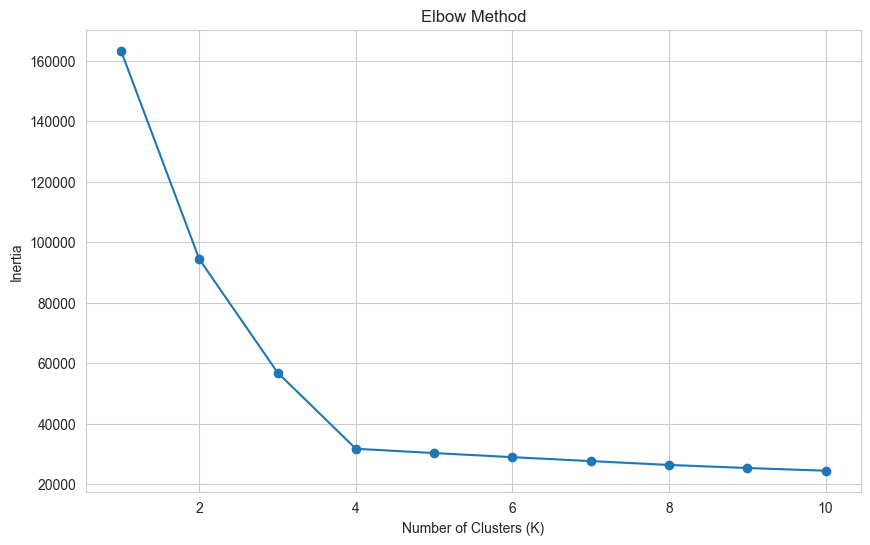

In [17]:

X = mental_cluster_dataset[['Depression', 'Anxiety', 'Schizophrenia', 'Bipolar']]
inertias = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.plot(range(1, 11), inertias, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [18]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
mental_cluster_dataset['KMeans_Cluster'] = km.fit_predict(X)

print(mental_cluster_dataset.groupby('KMeans_Cluster')[['Depression','Anxiety','Schizophrenia','Bipolar']].mean().round(2))

                Depression  Anxiety  Schizophrenia  Bipolar
KMeans_Cluster                                             
0                     5.01     7.97           3.03     2.01
1                     6.00     4.01           5.96     3.00
2                     7.05     1.98           1.93     0.98
3                     2.03     3.01           2.00     6.96


# Observations:

- Cluster 0 has the highest rate of anxiety, and second highest rates of depression.
- Cluster 1 has the highest rate of depression, and second highest rate of Schizophrenia
- Cluster 2 has the highest rate of depression, and second highest rate of anxiety(although all other disorders are fairly low with values between 1-2 compared to the depression value of 7) 
- Cluster 3 has the highest rate of Bipolar disorder, and the second highest rate of anxiety(though relatively low (3.01) compared to bipolar value(6.96))


because of this, cluster 0's treatment plans shoud focus on anxiety and depression medications, as well as qualitative options such as therapy to discuss 
symptoms and underlying trauma.

cluster 1 treatment plans should focus on both depression and schizophrenia medications which may be more psychiatric focused.

Cluster 2 treatment plans will mirror cluster 0 regarding therapy and depression+anxiety medication

Cluster 3 treatment plans will focus on psychiatric treatment for bipolar disorder as well as therapy for coping mechanisms.



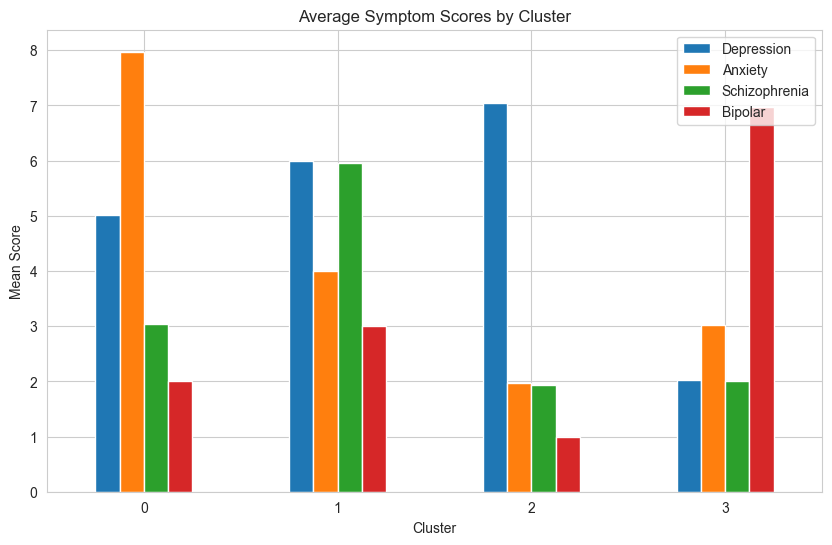

In [20]:
cluster_means = mental_cluster_dataset.groupby('KMeans_Cluster')[['Depression','Anxiety','Schizophrenia','Bipolar']].mean()
cluster_means.plot(kind='bar', figsize=(10, 6))
plt.title('Average Symptom Scores by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Mean Score')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.show()